/Users/jmdhanyakumar/task04/tfenv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Found 2627 files belonging to 10 classes.
Using 2102 files for training.
Found 2627 files belonging to 10 classes.
Using 525 files for validation.
Classes:
['Bacterial_Spot', 'Cercospora_leaf_mold', 'Early_Blight', 'Healthy', 'Insect_Damage', 'Late_Blight', 'Leaf_Miner', 'Leaf_Mold', 'Spider_Mites', 'Tomato_Leaf_Curl_Virus']
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 383ms/step - accuracy: 0.5918 - loss: 1.2069 - val_accuracy: 0.8648 - val_loss: 0.4782
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 405ms/step - accuracy: 0.8359 - loss: 0.4926 - val_accuracy: 0.8990 - val_loss: 0.3598
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 421ms/step - accuracy: 0.8868 - loss: 0.3442 - val_accuracy: 0.9314 - val_loss: 0.2344
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 427ms/step - accuracy: 0.9210 - loss: 0.2577 - val_accuracy: 0.8819 - val_loss: 0.3106
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 438ms/step - accuracy: 0.9401 - loss: 0.1898 - val_accuracy: 0.8762 - val_loss: 0.3294
Epoch 6/10
66/66 ━━━━━━━━━━━

Model Saved Successfully


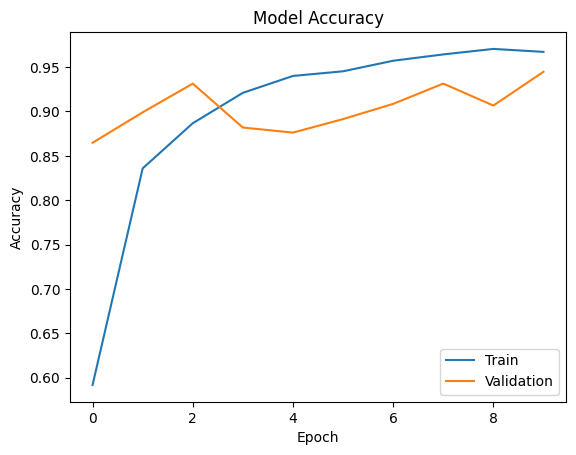

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# SETTINGS
IMG_SIZE = 224
BATCH_SIZE = 32
DATASET_PATH = "/Users/jmdhanyakumar/Desktop/MPROJECT/dataset"

# LOAD DATASET
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:")
print(class_names)

# DATA AUGMENTATION
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# LOAD MOBILENETV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# BUILD MODEL
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# COMPILE MODEL
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# SAVE MODEL
model.save("models/tomato_disease_model.h5")

print("Model Saved Successfully")

# PLOT ACCURACY
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()